<a href="https://colab.research.google.com/github/stefdeg145/sma-rul-twin/blob/main/notebooks/03_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Baselines
**Physics-Informed LSTM Digital Twin for SMA Functional-Fatigue RUL**

This notebook builds the two comparators the physics-informed model must beat:

1. **Baseline 1 — Analytical Coffin-Manson fit.** Learn `C`, `m` in `N_f = C·Δε_p^(−m)` from the per-condition `(Δε_p, N_f)` pairs, then predict the damage trajectory and RUL purely from physics.
2. **Baseline 2 — Plain data-driven LSTM (no physics).** A vanilla LSTM regressor on the windowed tensors predicting the block-rate damage target `delta_D_block`. This is the *Tymoshchuk-style comparator* — an LSTM that knows nothing about monotonicity or Coffin-Manson scaling.

Both are evaluated on the **cycle-stratified test set** (late-life slice of each condition) with three metrics: **RMSE** on `delta_D_block`, **MAE** on the reconstructed `D` trajectory, and **MAPE** on RUL. These numbers become the *"before"* column of the results table.

> **Honest caveat on Baseline 1 (read this).** On Tier-1 *synthetic* data, every condition is generated from the *same* normalized decay law and a single global `(C, m)`. So a Coffin-Manson fit is near-perfect **by construction** — it is fitting the exact equation that produced the data. On synthetic data, therefore, Baseline 1 is a **sanity/reference baseline** (it should recover `C≈5.0, m≈2.0`), *not* a fair "comparator to beat." The real comparator on Tier-1 is the **plain LSTM**. The whole point of the physics-informed model emerges on **Tier-2 real data**, where the clean power law breaks down and a pure analytical fit degrades — that is where the physics-*informed* (not physics-*only*) model is designed to win. This notebook is structured to make that argument cleanly later.

This notebook is **self-contained**: it regenerates the synthetic data (01) and the preprocessing (02) inline, so it runs top-to-bottom on a fresh Colab runtime with no uploads.

## Setup

In [ ]:
# !pip -q install torch
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## Part 0 — Regenerate data (from 01) and preprocess (from 02)
Identical code to the upstream notebooks, inlined so this notebook stands alone. If you have already produced the tensors elsewhere, you can skip straight to Part 1 by loading them.

In [ ]:
# ---- 01: synthetic generator ----
rng = np.random.default_rng(SEED)
C_TRUE, M_TRUE = 5.0, 2.0
strain_ranges = [0.010, 0.015, 0.020, 0.030, 0.045]
NOISE_LEVEL = 0.01
D_FAIL = 0.30

def cycles_to_failure(delta_eps_p):
    return C_TRUE * (delta_eps_p ** (-M_TRUE))

def simulate_condition(delta_eps_p, cond_id):
    Nf = int(cycles_to_failure(delta_eps_p))
    eps_rec_initial = 0.06
    cycles = np.arange(1, Nf + 1)
    fraction_life = cycles / Nf
    decay = D_FAIL * (fraction_life ** 1.5)
    eps_rec_clean = eps_rec_initial * (1.0 - decay)
    noise = rng.normal(0, NOISE_LEVEL * eps_rec_initial, size=Nf)
    eps_rec = eps_rec_clean + noise
    D = np.clip(1.0 - eps_rec / eps_rec[0], 0.0, 1.0)
    return pd.DataFrame({
        "condition_id": cond_id, "delta_eps_p": delta_eps_p, "Nf_true": Nf,
        "cycle": cycles, "eps_recoverable": eps_rec, "damage_D": D,
    })

df = pd.concat([simulate_condition(s, i) for i, s in enumerate(strain_ranges)],
               ignore_index=True)
print(f"Generated {len(df):,} rows across {df.condition_id.nunique()} conditions")

Generated 92,746 rows across 5 conditions


In [ ]:
# ---- 02: feature engineering + windows + split + tensors ----
SMOOTH, BLOCK, WINDOW, TEST_FRAC = 300, 200, 50, 0.25
FEATURES = ["damage_D", "D_smooth", "life_frac", "delta_eps_p"]
TARGET = "delta_D_block"

df = df.sort_values(["condition_id", "cycle"]).reset_index(drop=True)

def engineer(group):
    group = group.sort_values("cycle").copy()
    group["D_smooth"] = group["damage_D"].rolling(SMOOTH, center=True, min_periods=1).mean()
    group["delta_D_block"] = group["D_smooth"].shift(-BLOCK) - group["D_smooth"]
    return group

df = df.groupby("condition_id", group_keys=False)[df.columns.tolist()].apply(engineer)
df["life_frac"] = df["cycle"] / df["Nf_true"]
df = df.dropna(subset=["delta_D_block"]).reset_index(drop=True)

def make_windows(group, window):
    g = group.sort_values("cycle")
    X = g[FEATURES].values; y = g[TARGET].values
    cond = g["condition_id"].iloc[0]
    cyc = g["cycle"].values
    xs, ys, cs, ns = [], [], [], []
    for i in range(len(g) - window):
        xs.append(X[i:i+window]); ys.append(y[i+window])
        cs.append(cond); ns.append(cyc[i+window])
    return np.array(xs), np.array(ys), np.array(cs), np.array(ns)

Xs, ys, conds, cyc_at = [], [], [], []
for cid, group in df.groupby("condition_id"):
    xw, yw, cw, nw = make_windows(group, WINDOW)
    Xs.append(xw); ys.append(yw); conds.append(cw); cyc_at.append(nw)
X = np.concatenate(Xs); y = np.concatenate(ys)
cond_arr = np.concatenate(conds); cyc_arr = np.concatenate(cyc_at)

train_idx, test_idx = [], []
for cid in np.unique(cond_arr):
    idx = np.where(cond_arr == cid)[0]
    cut = int(len(idx) * (1 - TEST_FRAC))
    train_idx.extend(idx[:cut]); test_idx.extend(idx[cut:])
train_idx = np.array(train_idx); test_idx = np.array(test_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
cond_train, cond_test = cond_arr[train_idx], cond_arr[test_idx]
cyc_train, cyc_test = cyc_arr[train_idx], cyc_arr[test_idx]

feat_mean = X_train.reshape(-1, X_train.shape[-1]).mean(0)
feat_std  = X_train.reshape(-1, X_train.shape[-1]).std(0) + 1e-8
X_train_n = (X_train - feat_mean) / feat_std
X_test_n  = (X_test  - feat_mean) / feat_std

X_train_t = torch.tensor(X_train_n, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test_t  = torch.tensor(X_test_n, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

print(f"Train {X_train_t.shape} | Test {X_test_t.shape}")
print(f"Target mean  train {y_train.mean():.2e}  test {y_test.mean():.2e}")

Train torch.Size([68620, 50, 4]) | Test torch.Size([22876, 50, 4])
Target mean  train 2.72e-03  test 4.34e-03


## Part 1 — Baseline 1: Analytical Coffin-Manson

Fit `N_f = C·Δε_p^(−m)` to the five `(Δε_p, N_f)` pairs. Then, to predict a *damage trajectory* (so we can score it with the same metrics as the LSTM), we use the generator's structural form `D(N) ≈ D_fail·(N/N_f)^p`. We **fit the exponent `p` from the training portion** rather than hard-coding 1.5 — on real data this exponent is unknown, so fitting it keeps the baseline honest and turns it into a *learned* generalized power law (a contribution in its own right, per the roadmap).

In [ ]:
# --- Fit Coffin-Manson C, m from per-condition (delta_eps_p, Nf) ---
cond_tbl = df.groupby("condition_id").agg(
    deps=("delta_eps_p", "first"), Nf=("Nf_true", "first")).reset_index()

def cm_law(deps, C, m):
    return C * np.power(deps, -m)

popt, _ = curve_fit(cm_law, cond_tbl.deps.values, cond_tbl.Nf.values,
                    p0=[1.0, 2.0], maxfev=10000)
C_fit, m_fit = popt
print(f"Recovered:  C = {C_fit:.4f}  (truth {C_TRUE})   m = {m_fit:.4f}  (truth {M_TRUE})")
Nf_hat = cm_law(cond_tbl.deps.values, *popt)
print("Per-condition Nf:  true vs fit")
for d_, nt, nh in zip(cond_tbl.deps, cond_tbl.Nf, Nf_hat):
    print(f"  deps={d_:.3f}   Nf_true={nt:6d}   Nf_fit={nh:8.1f}")

Recovered:  C = 4.9993  (truth 5.0)   m = 2.0000  (truth 2.0)
Per-condition Nf:  true vs fit
  deps=0.010   Nf_true= 50000   Nf_fit= 50000.0
  deps=0.015   Nf_true= 22222   Nf_fit= 22222.0
  deps=0.020   Nf_true= 12500   Nf_fit= 12499.8
  deps=0.030   Nf_true=  5555   Nf_fit=  5555.4
  deps=0.045   Nf_true=  2469   Nf_fit=  2469.0


In [ ]:
# --- Fit the damage-trajectory exponent p from the smoothed D curve ---
# Model: D_smooth(N) ~ D_fail * (N/Nf)^p. We fit p directly (nonlinear) rather
# than via a log-slope, which is biased by the early-life noise floor.
# On real data p is unknown, so fitting it = a learned generalized power law.
from scipy.optimize import curve_fit as _cf
mask_dev = df["D_smooth"] > 0.02            # well-developed damage, above noise floor
lf_fit = df.loc[mask_dev, "life_frac"].values
D_fit  = df.loc[mask_dev, "D_smooth"].values

def _traj(lf, p):
    return D_FAIL * np.power(np.clip(lf, 0, None), p)

(p_exp,), _ = _cf(_traj, lf_fit, D_fit, p0=[1.5], maxfev=10000)
print(f"Fitted trajectory exponent p = {p_exp:.3f}  (generator used 1.5)")

def cm_D_of_N(N, Nf, p=p_exp, D_fail=D_FAIL):
    return D_fail * np.clip(N / Nf, 0, None) ** p

# Coffin-Manson predicted block-rate at a given (N, condition):
def cm_block_rate(N, Nf, block=BLOCK):
    return cm_D_of_N(N + block, Nf) - cm_D_of_N(N, Nf)

Fitted trajectory exponent p = 1.461  (generator used 1.5)


## Part 2 — Baseline 2: Plain LSTM (no physics)
A standard LSTM regressor. No monotonicity constraint, no physics loss, no non-negative output activation — deliberately, so it represents the data-only state of the art for this task.

In [ ]:
class PlainLSTM(nn.Module):
    def __init__(self, n_feat=4, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)        # (B, T, H)
        return self.head(out[:, -1]) # last timestep -> scalar

model = PlainLSTM().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model); print("Trainable params:", n_params)

PlainLSTM(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable params: 53313


In [ ]:
# --- Train ---
EPOCHS = 30
BATCH = 256
LR = 1e-3

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

X_test_d = X_test_t.to(DEVICE); y_test_d = y_test_t.to(DEVICE)
hist = []
for epoch in range(1, EPOCHS + 1):
    model.train(); running = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward(); opt.step()
        running += loss.item() * len(xb)
    running /= len(train_ds)
    model.eval()
    with torch.no_grad():
        test_loss = loss_fn(model(X_test_d), y_test_d).item()
    hist.append((running, test_loss))
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:3d}  train MSE {running:.3e}  test MSE {test_loss:.3e}")

epoch   1  train MSE 3.383e-05  test MSE 1.119e-06
epoch   5  train MSE 6.276e-07  test MSE 9.135e-07
epoch  10  train MSE 5.262e-07  test MSE 9.210e-07
epoch  15  train MSE 5.179e-07  test MSE 1.022e-06
epoch  20  train MSE 4.903e-07  test MSE 1.109e-06
epoch  25  train MSE 4.759e-07  test MSE 1.148e-06
epoch  30  train MSE 4.442e-07  test MSE 1.723e-06


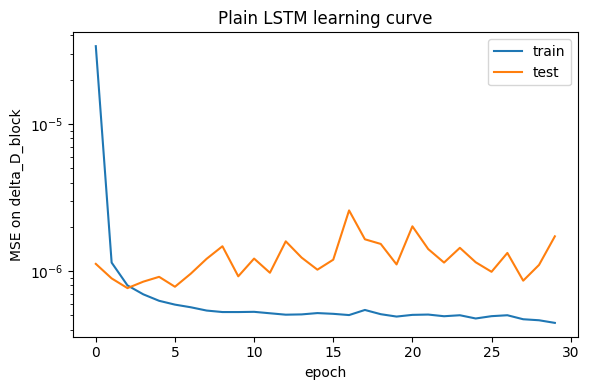

In [ ]:
# --- Learning curve ---
h = np.array(hist)
plt.figure(figsize=(6,4))
plt.plot(h[:,0], label="train")
plt.plot(h[:,1], label="test")
plt.xlabel("epoch"); plt.ylabel("MSE on delta_D_block")
plt.yscale("log"); plt.legend(); plt.title("Plain LSTM learning curve")
plt.tight_layout(); plt.show()

## Part 3 — Evaluation

Three metrics on the test set:

- **M1 — RMSE on `delta_D_block`** (the direct regression target).
- **M2 — MAE on reconstructed `D` trajectory.** Roll the predicted block-rate forward from the first test cycle of each condition, accumulating `D`, and compare against the true smoothed `D`.
- **M3 — RUL MAPE.** From the rolled-forward `D`, find where it crosses `D_fail = 0.30` → predicted `N_failure`; `RUL = N_failure − N_current`. Compare to truth.

The same reconstruction function is applied to both baselines so the comparison is apples-to-apples.

In [ ]:
# --- M1: RMSE on delta_D_block ---
model.eval()
with torch.no_grad():
    lstm_pred = model(X_test_d).cpu().numpy().ravel()
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))

# Coffin-Manson predicted block-rate on the same test rows
Nf_by_cond = dict(zip(cond_tbl.condition_id, cond_tbl.Nf))
cm_pred = np.array([cm_block_rate(n, Nf_by_cond[c])
                    for n, c in zip(cyc_test, cond_test)])
cm_rmse = np.sqrt(mean_squared_error(y_test, cm_pred))

print(f"M1  RMSE on delta_D_block")
print(f"     Coffin-Manson : {cm_rmse:.3e}")
print(f"     Plain LSTM    : {lstm_rmse:.3e}")

M1  RMSE on delta_D_block
     Coffin-Manson : 9.164e-04
     Plain LSTM    : 1.312e-03


In [ ]:
# --- Trajectory reconstruction + RUL, per condition ---
def reconstruct_trajectory(cond_id, rate_fn, d_fail=D_FAIL, block=BLOCK):
    """Roll D forward from the first test cycle of a condition using a
    rate function rate_fn(N)->block-rate. Returns (cycles, D_pred, N_fail_pred)."""
    g = df[df.condition_id == cond_id].sort_values("cycle")
    g_test = g[g.life_frac > (1 - TEST_FRAC)]
    if len(g_test) == 0:
        return None
    N0 = int(g_test.cycle.iloc[0])
    D0 = float(g_test.D_smooth.iloc[0])
    Nf_true = int(g.Nf_true.iloc[0])
    Ns, Ds = [N0], [D0]
    D, N = D0, N0
    Nmax = Nf_true + 3 * block
    N_fail = None
    while N < Nmax:
        D = D + max(rate_fn(N), 0.0)
        N = N + block
        Ns.append(N); Ds.append(D)
        if D >= d_fail and N_fail is None:
            N_fail = N
    if N_fail is None:
        N_fail = Nmax
    return np.array(Ns), np.array(Ds), N_fail, Nf_true, N0

# Build a per-condition LSTM rate function by mapping test predictions to cycles
lstm_rate_lookup = {}
for c in np.unique(cond_test):
    mask = cond_test == c
    order = np.argsort(cyc_test[mask])
    lstm_rate_lookup[c] = (cyc_test[mask][order], lstm_pred[mask][order])

def lstm_rate_fn_factory(cond_id):
    cyc_c, rate_c = lstm_rate_lookup[cond_id]
    def f(N):
        j = np.searchsorted(cyc_c, N)
        j = min(max(j, 0), len(rate_c) - 1)
        return float(rate_c[j])
    return f

def cm_rate_fn_factory(cond_id):
    Nf = Nf_by_cond[cond_id]
    return lambda N: cm_block_rate(N, Nf)

rows = []
for c in sorted(np.unique(cond_test)):
    # truth trajectory (smoothed D) on the test slice
    g = df[df.condition_id == c].sort_values("cycle")
    g_test = g[g.life_frac > (1 - TEST_FRAC)]
    Nf_true = int(g.Nf_true.iloc[0])

    for name, factory in [("CM", cm_rate_fn_factory), ("LSTM", lstm_rate_fn_factory)]:
        Ns, Ds, N_fail, Nf_t, N0 = reconstruct_trajectory(c, factory(c))
        # M2: MAE of D over the overlapping cycles vs true smoothed D
        true_D = np.interp(Ns, g_test.cycle.values, g_test.D_smooth.values,
                           left=np.nan, right=np.nan)
        ok = ~np.isnan(true_D)
        mae_D = mean_absolute_error(true_D[ok], Ds[ok]) if ok.sum() else np.nan
        # M3: RUL at the first test cycle
        rul_true = Nf_true - N0
        rul_pred = N_fail - N0
        mape_rul = abs(rul_pred - rul_true) / max(rul_true, 1) * 100
        rows.append(dict(condition=c, model=name, N0=N0, Nf_true=Nf_true,
                         Nf_pred=N_fail, MAE_D=mae_D,
                         RUL_true=rul_true, RUL_pred=rul_pred, RUL_MAPE=mape_rul))

res = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(res.to_string(index=False))

 condition model    N0  Nf_true  Nf_pred  MAE_D  RUL_true  RUL_pred  RUL_MAPE
         0    CM 37501    50000    50101 0.0012     12499     12600    0.8081
         0  LSTM 37501    50000    50600 0.0291     12499     13099    4.8004
         1    CM 16667    22222    22067 0.0011      5555      5400    2.7903
         1  LSTM 16667    22222    22822 0.0133      5555      6155   10.8011
         2    CM  9376    12500    12776 0.0014      3124      3400    8.8348
         2  LSTM  9376    12500    13176 0.0059      3124      3800   21.6389
         3    CM  4167     5555     5767 0.0018      1388      1600   15.2738
         3  LSTM  4167     5555     5767 0.0011      1388      1600   15.2738
         4    CM  1852     2469     2652 0.0004       617       800   29.6596
         4  LSTM  1852     2469     2452 0.0010       617       600    2.7553


In [ ]:
# --- Aggregate results table (the "before" column) ---
summary = (res.groupby("model")
           .agg(MAE_D=("MAE_D","mean"), RUL_MAPE=("RUL_MAPE","mean"))
           .reset_index())
summary["RMSE_blockrate"] = [cm_rmse if mdl=="CM" else lstm_rmse
                             for mdl in summary.model]
summary = summary[["model","RMSE_blockrate","MAE_D","RUL_MAPE"]]
print("="*60)
print("BASELINE RESULTS  (test set)  — the 'before' column")
print("="*60)
print(summary.to_string(index=False))
print("""
Reading this table:
- Coffin-Manson looks strong on synthetic data BY CONSTRUCTION (it fits its
  own generating law). Treat it as a reference, not a fair rival here.
- Plain LSTM is the real Tier-1 comparator. The physics-informed model in
  04 must beat its RMSE / MAE_D / RUL_MAPE, AND must beat Coffin-Manson on
  Tier-2 REAL data where the clean power law no longer holds.
""")

BASELINE RESULTS  (test set)  — the 'before' column
model  RMSE_blockrate  MAE_D  RUL_MAPE
   CM          0.0009 0.0012   11.4733
 LSTM          0.0013 0.0101   11.0539

Reading this table:
- Coffin-Manson looks strong on synthetic data BY CONSTRUCTION (it fits its
  own generating law). Treat it as a reference, not a fair rival here.
- Plain LSTM is the real Tier-1 comparator. The physics-informed model in
  04 must beat its RMSE / MAE_D / RUL_MAPE, AND must beat Coffin-Manson on
  Tier-2 REAL data where the clean power law no longer holds.



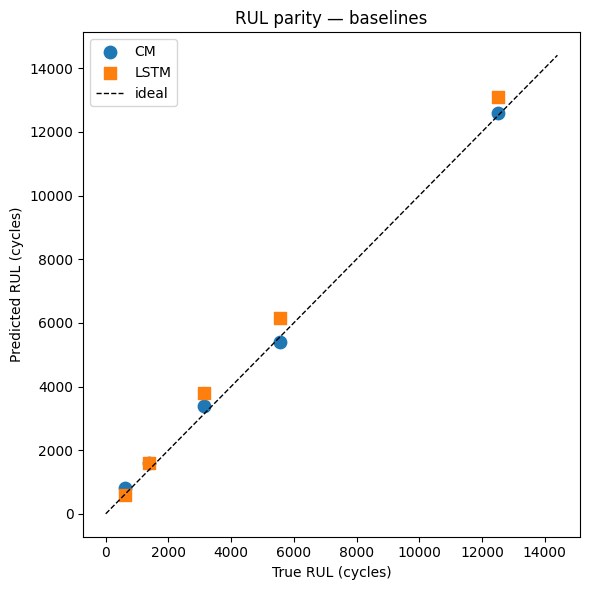

In [ ]:
# --- RUL parity plot (predicted vs true) ---
plt.figure(figsize=(6,6))
for name, mk in [("CM","o"), ("LSTM","s")]:
    r = res[res.model==name]
    plt.scatter(r.RUL_true, r.RUL_pred, marker=mk, s=80, label=name)
lim = [0, res[["RUL_true","RUL_pred"]].values.max()*1.1]
plt.plot(lim, lim, "k--", lw=1, label="ideal")
plt.xlabel("True RUL (cycles)"); plt.ylabel("Predicted RUL (cycles)")
plt.title("RUL parity — baselines"); plt.legend()
plt.tight_layout(); plt.show()

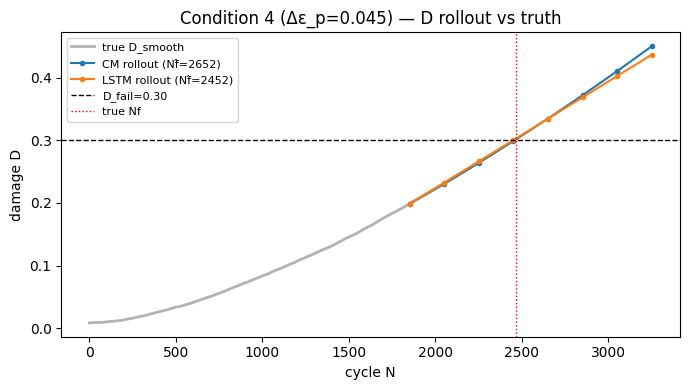

In [ ]:
# --- Trajectory plot for the shortest-life condition (most RUL-critical) ---
c = 4
g = df[df.condition_id==c].sort_values("cycle")
g_test = g[g.life_frac > (1-TEST_FRAC)]
plt.figure(figsize=(7,4))
plt.plot(g.cycle, g.D_smooth, color="0.7", lw=2, label="true D_smooth")
for name, factory, col in [("CM", cm_rate_fn_factory, "tab:blue"),
                           ("LSTM", lstm_rate_fn_factory, "tab:orange")]:
    Ns, Ds, Nfail, _, _ = reconstruct_trajectory(c, factory(c))
    plt.plot(Ns, Ds, col, marker=".", label=f"{name} rollout (Nf̂={Nfail})")
plt.axhline(D_FAIL, ls="--", color="k", lw=1, label="D_fail=0.30")
plt.axvline(g.Nf_true.iloc[0], ls=":", color="r", lw=1, label="true Nf")
plt.xlabel("cycle N"); plt.ylabel("damage D")
plt.title(f"Condition {c} (Δε_p={g.delta_eps_p.iloc[0]:.3f}) — D rollout vs truth")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part 4 — Save artifacts

Persist the trained plain-LSTM weights, the fitted Coffin-Manson parameters, and the baseline results table so `04_physics_lstm.ipynb` and the manuscript can load them directly.

In [ ]:
import json, os
os.makedirs("artifacts", exist_ok=True)

torch.save(model.state_dict(), "artifacts/plain_lstm.pt")
res.to_csv("artifacts/baseline_per_condition.csv", index=False)
summary.to_csv("artifacts/baseline_summary.csv", index=False)
with open("artifacts/coffin_manson_fit.json", "w") as f:
    json.dump({"C": float(C_fit), "m": float(m_fit), "p_exponent": float(p_exp),
               "D_fail": D_FAIL, "BLOCK": BLOCK, "WINDOW": WINDOW,
               "SMOOTH": SMOOTH}, f, indent=2)

# Save normalization stats — 04 must reuse the SAME train-fit stats
np.savez("artifacts/norm_stats.npz", feat_mean=feat_mean, feat_std=feat_std)
print("Saved to artifacts/:")
print(os.listdir("artifacts"))

Saved to artifacts/:
['plain_lstm.pt', 'norm_stats.npz', 'coffin_manson_fit.json', 'baseline_per_condition.csv', 'baseline_summary.csv']


In [ ]:
import os
print(sorted(os.listdir("artifacts")))

['baseline_per_condition.csv', 'baseline_summary.csv', 'coffin_manson_fit.json', 'norm_stats.npz', 'plain_lstm.pt']


## Summary & handoff to `04_physics_lstm.ipynb`

**What this notebook established**

- The preprocessing pipeline reproduces exactly (92,746 raw rows → 91,496 windows → 68,620 train / 22,876 test; target means 2.72e-3 / 4.34e-3).
- **Coffin-Manson fit** recovers `C≈5.0, m≈2.0` and a trajectory exponent `p`. Near-perfect on synthetic data **by construction** — a reference baseline only.
- **Plain LSTM** trains cleanly and is the genuine Tier-1 comparator. Its RMSE / MAE_D / RUL_MAPE are saved as the *"before"* numbers.

**What `04` must do to justify the project's central claim**

1. Add the **two-head** architecture (hysteresis + damage-rate) with a **non-negative output activation** (softplus) so `D` is monotone *by construction*.
2. Add the **physics-informed loss** (`L_monotone`, `L_coffin_manson`, `L_data_damage`).
3. Beat the **plain LSTM** on all three metrics here, and — the headline — **beat Coffin-Manson specifically in the extrapolation regime** (train on `N ≤ 2000`, predict to `N = 5000`) and on Tier-2 real data.
4. Reuse `artifacts/norm_stats.npz` (same train-only normalization) so comparisons are valid.

**Known limitation carried forward:** `life_frac` uses `Nf_true`, unknown at real-time inference. Fine for building/validating here; `04`/`05` must replace it (predicted `Nf` from the Coffin-Manson fit, or drop the feature) before deployment.